Lab 2: Understanding Probablility in Binary Classification

ML problem
use Breast cancer dataset
the task is to predict whether a tumour is : malignant or benign

In [ ]:
#import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
#load dataset
data = load_breast_cancer()

X=pd.DataFrame(data.data,columns=data.feature_names)

y=pd.Series((data.target==0).astype(int),name="malignant")

print(y.value_counts())

print("Feature matrix shape: ",X.shape)
print("Target shape: ",y.shape)
print("Class names: ",data.target_names)


malignant
0    357
1    212
Name: count, dtype: int64
Feature matrix shape:  (569, 30)
Target shape:  (569,)
Class names:  ['malignant' 'benign']


In [ ]:
#Examine the class Distribution

class_counts=y.value_counts().sort_index()
class_distribution=pd.DataFrame({
    "class":data.target_names,
    "count":class_counts.values,
    "Probability":class_counts.values/len(y)})
print(class_distribution)

       class  count  Probability
0  malignant    357     0.627417
1     benign    212     0.372583


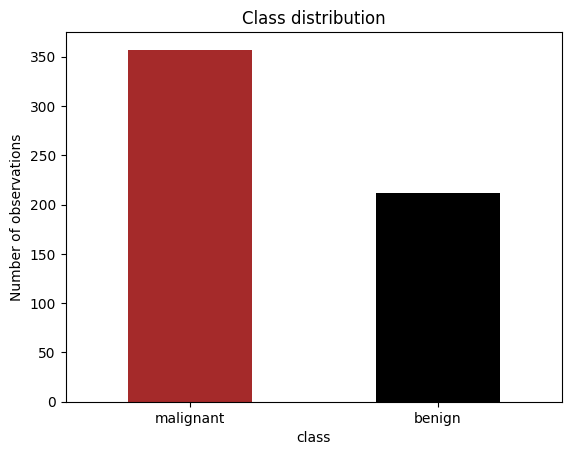

In [ ]:
class_distribution.plot(
                        x="class",
                        y="count",
                        kind="bar",
                        legend=False,
                        color=["brown","black"]
                        )
plt.ylabel("Number of observations")
plt.title("Class distribution")
plt.xticks(rotation=0)
plt.show()

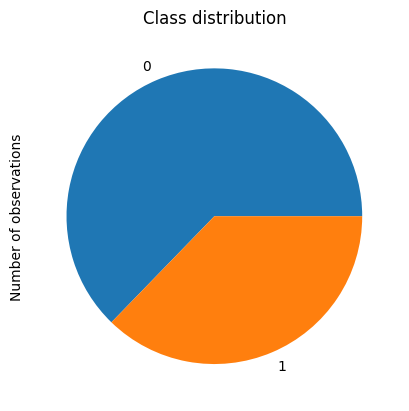

In [ ]:
class_distribution.plot(
                        x="class",
                        y="count",
                        kind="pie",
                        legend=False,
                        color=["tomato","steelblue"]
                        )
plt.ylabel("Number of observations")
plt.title("Class distribution")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#create training and testing samples
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("training Size: ",len(y_train))
print("testing Size: ",len(y_test))

print("\nTraining Proportions: ")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting Proportions: ")
print(y_test.value_counts(normalize=True).sort_index())

training Size:  455
testing Size:  114

Training Proportions: 
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing Proportions: 
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [ ]:
#train A LOGISTIC regression Model
model=make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model.fit(X_train,y_train)



Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [ ]:
#obtain predicted probabilities
probabilities=model.predict_proba(X_test)

print(probabilities[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [ ]:
print(probabilities)

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]
 [9.99383998e-01 6.16001620e-04]
 [2.38465914e-01 7.61534086e-01]
 [9.98987828e-01 1.01217174e-03]
 [9.99431274e-01 5.68725516e-04]
 [9.89232420e-01 1.07675795e-02]
 [6.90940474e-02 9.30905953e-01]
 [9.99927168e-01 7.28319772e-05]
 [1.00901925e-07 9.99999899e-01]
 [9.95605507e-01 4.39449272e-03]
 [9.92247374e-01 7.75262630e-03]
 [9.99998294e-01 1.70641370e-06]
 [9.38570567e-01 6.14294329e-02]
 [9.99637188e-01 3.62811536e-04]
 [7.78237987e-01 2.21762013e-01]
 [9.99949272e-01 5.07279789e-05]
 [9.98733772e-01 1.26622816e-03]
 [9.95696579e-01 4.30342121e-03]
 [4.19456022e-07 9.99999581e-01]
 [1.67847563e-03 9.98321524e-01]
 [2.42393094e-01 7.57606906e-01]
 [9.99794119e-01 2.05880632e-04]
 [9.99831320e-01 1.68680282e-04]
 [3.08285807e-02 9.69171419e-01]
 [3.36047094e-03 9.96639529e-01]
 [4.20355886e-04 9.99579644e-01]
 [8.146348

In [ ]:
results=pd.DataFrame({
    "actual_class":y_test.values,
    "P_malignant": probabilities[:,0],
    "P_benign":probabilities[:,1]
})

print(results.head(10))

   actual_class   P_malignant  P_benign
0             0  9.996354e-01  0.000365
1             1  1.074660e-08  1.000000
2             0  9.574321e-01  0.042568
3             1  4.238127e-01  0.576187
4             0  4.908445e-01  0.509155
5             0  9.993840e-01  0.000616
6             1  2.384659e-01  0.761534
7             0  9.989878e-01  0.001012
8             0  9.994313e-01  0.000569
9             0  9.892324e-01  0.010768


In [ ]:
results["Actual_label"]=results["actual_class"].map({1:"malignant",0:"benign"})
print(results[
    ["Actual_label","P_malignant","P_benign"]
].head(10)
      )

  Actual_label   P_malignant  P_benign
0       benign  9.996354e-01  0.000365
1    malignant  1.074660e-08  1.000000
2       benign  9.574321e-01  0.042568
3    malignant  4.238127e-01  0.576187
4       benign  4.908445e-01  0.509155
5       benign  9.993840e-01  0.000616
6    malignant  2.384659e-01  0.761534
7       benign  9.989878e-01  0.001012
8       benign  9.994313e-01  0.000569
9       benign  9.892324e-01  0.010768


In [ ]:
#use a threshold to genearte pridictions
threshold=0.50

results["Predicted_malignant"]=(
    results["P_malignant"]>threshold
).astype(int)

results["Predicted_label"]=results["Predicted_malignant"].map({1:"malignant",0:"benign"})

print(results[
    ["Actual_label","Predicted_label","P_malignant","P_benign"]
].head(10)
)

  Actual_label Predicted_label   P_malignant  P_benign
0       benign       malignant  9.996354e-01  0.000365
1    malignant          benign  1.074660e-08  1.000000
2       benign       malignant  9.574321e-01  0.042568
3    malignant          benign  4.238127e-01  0.576187
4       benign          benign  4.908445e-01  0.509155
5       benign       malignant  9.993840e-01  0.000616
6    malignant          benign  2.384659e-01  0.761534
7       benign       malignant  9.989878e-01  0.001012
8       benign       malignant  9.994313e-01  0.000569
9       benign       malignant  9.892324e-01  0.010768


In [ ]:
#compare different thresholds
for thresholds in [0.30,0.50,0.70]:
  predictions=(
      results["P_malignant"]>=threshold
  ).astype(int)

  print(
      f"Threshold={threshold}:"
      f"predicted malignant cases = {predictions.sum()}"
  )

Threshold=0.5:predicted malignant cases = 74
Threshold=0.5:predicted malignant cases = 74
Threshold=0.5:predicted malignant cases = 74


In [ ]:
actual_malignant= (y_test.values==0).astype(int)

for threshold in [0.30,0.50,0.70]:
  predicted_malignant=(
      probabilities[:,0]>=threshold
  ).astype(int)

  cm=confusion_matrix(
      actual_malignant,
      predicted_malignant
  )

  print(f"\nThreshold={threshold}:")
  print(cm)



Threshold=0.3:
[[38  4]
 [ 0 72]]

Threshold=0.5:
[[39  3]
 [ 1 71]]

Threshold=0.7:
[[41  1]
 [ 1 71]]


**Accuracy= TP + TN / TP+TN+FP+FN**

**Precison = TP / TP+FP**

**Recall = sensitivity = TP / TP+FN**

**Specificity = TN / TN+FP**

**F1 = 2(Precision x Recall / Precision + Recall)**

In [ ]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
y_pred=model.predict(X_test)
print(
    "sklearn Accuracy: ",
    accuracy_score(y_test, y_pred)
)

print(
    "sklearn Precision: ",
    precision_score(y_test, y_pred))


print(
    "sklearn Recall: ",
    recall_score(y_test,y_pred)
)

print(
    "sklearn F1: ",
    f1_score(y_test, y_pred)
)

sklearn Accuracy:  0.9649122807017544
sklearn Precision:  0.975
sklearn Recall:  0.9285714285714286
sklearn F1:  0.9512195121951219


In [ ]:
thresholds = [0.1, 0.30, 0.50, 0.70, 0.90]
metrics_data = []

for threshold in thresholds:
    predicted_malignant = (probabilities[:, 1] >= threshold).astype(int)

    cm = confusion_matrix(y_test, predicted_malignant, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    metrics_data.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, predicted_malignant),
        'Precision': precision_score(y_test, predicted_malignant),
        'Recall': recall_score(y_test, predicted_malignant),
        'F1-score': f1_score(y_test, predicted_malignant),
        'TN': TN,
        'FP': FP,
        'FN': FN,
        'TP': TP
    })

threshold_metrics = pd.DataFrame(metrics_data)
display(threshold_metrics.round(3))

,Threshold,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
0,0.1,0.947,0.891,0.976,0.932,67,5,1,41
1,0.3,0.982,0.976,0.976,0.976,71,1,1,41
2,0.5,0.965,0.975,0.929,0.951,71,1,3,39
3,0.7,0.965,1.000,0.905,0.950,72,0,4,38
4,0.9,0.921,1.000,0.786,0.880,72,0,9,33
